# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game player data, splitting into train/test sets, creating datasets and
dataloaders from them, hyperparameter tuning a `FootballLSTM` instance, training it,
and evaluating it.

In [1]:
import sys
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset, merge_stats_df_with_transfermarkt
from football_lstm import FootballLSTM
from utils import hyperparam_tuning, get_actuals_vs_predictions_df

In [2]:
# have GPU available to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cpu


In [3]:
# Choose what stats to forecast, what position(s) to use, 
# how many past games to predict future games
stats = ["xG", "xA", "xGChain"]
per_90_stats = list(map(lambda s: f"{s}_per_90", stats))
positions = ['M']
blocks_per_input = 10

In [4]:
# Read in saved df - use pull_understat_data as needed if desired data hasn't been pulled
stats_df = pd.read_csv(f"../data/{'_'.join(positions)}_stats.csv")

# Convert date to appropriate type
stats_df['date'] = pd.to_datetime(stats_df['date'])

stats_df = stats_df.set_index(['player_id', 'player_name', 'date', 'league'])

stats_df = stats_df[per_90_stats] # Only include appropriate stats

stats_df.head()

xG_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.040743   
                            2015-03-22 14:30:00 Bundesliga   0.021087   
                            2015-09-12 17:30:00 Bundesliga   0.079120   
                            2015-11-29 20:30:00 Bundesliga   0.072270   
                            2016-03-19 18:30:00 Bundesliga   0.047304   

                                                            xA_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.035318   
                            2015-03-22 14:30:00 Bundesliga   0.005730   
                            2015-09-12 17:30:00 Bundesliga   0.025244   
                            2015-11-29 20:30:00 Bundesliga   0.010650   
                            2016-03-19 18:30:00 Bundesliga   0.031790   

                                                            xGChain_per_90  
player_id player_name       date                league                      
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga        0.250601  
                            2015-03-22 14:30:00 Bundesliga        0.287882  
                            2015-09-12 17:30:00 Bundesliga        0.487742  
                            2015-11-29 20:30:00 Bundesliga        0.398019  
                            2016-03-19 18:30:00 Bundesliga        0.377149

In [5]:
# Train/test split by player
all_players = stats_df.index.get_level_values('player_id').unique()

# 80/20 split
np.random.seed(42)
train_players = np.random.choice(all_players, size=int(0.8*len(all_players)), replace=False)

train_df = stats_df[stats_df.index.get_level_values('player_id').isin(train_players)].copy()
test_df = stats_df[~stats_df.index.get_level_values('player_id').isin(train_players)].copy()

In [6]:
train_df.head()

xG_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.040743   
                            2015-03-22 14:30:00 Bundesliga   0.021087   
                            2015-09-12 17:30:00 Bundesliga   0.079120   
                            2015-11-29 20:30:00 Bundesliga   0.072270   
                            2016-03-19 18:30:00 Bundesliga   0.047304   

                                                            xA_per_90  \
player_id player_name       date                league                  
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga   0.035318   
                            2015-03-22 14:30:00 Bundesliga   0.005730   
                            2015-09-12 17:30:00 Bundesliga   0.025244   
                            2015-11-29 20:30:00 Bundesliga   0.010650   
                            2016-03-19 18:30:00 Bundesliga   0.031790   

                                                            xGChain_per_90  
player_id player_name       date                league                      
150       Josuha Guilavogui 2014-11-22 14:30:00 Bundesliga        0.250601  
                            2015-03-22 14:30:00 Bundesliga        0.287882  
                            2015-09-12 17:30:00 Bundesliga        0.487742  
                            2015-11-29 20:30:00 Bundesliga        0.398019  
                            2016-03-19 18:30:00 Bundesliga        0.377149

In [7]:
# Winsorize dfs - this step alone drops RMSE by nearly 100 mil in the Bayesian!!
caps = np.percentile(train_df[per_90_stats].values, 95, axis=0)
# Save for use in R later
pd.DataFrame({'stat': per_90_stats, 'cap': caps}).to_csv(f'../data/{"_".join(positions)}_winsorize_params.csv', index=False)
train_df.loc[:,per_90_stats] = np.clip(train_df[per_90_stats], 0, caps)
test_df.loc[:,per_90_stats] = np.clip(test_df[per_90_stats], 0, caps)

In [8]:
# Create datasets

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [9]:
len(train_dataset)

6833

In [10]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
# Tuning params
params = {
    "learning_rates": [0.001, .0001],      
    "epochs": [20, 50],        
    "layers": [1, 2],                            
    "h_sizes": [32, 64, 128, 256],                  
    "dropouts": [0.3, 0.5]                
}

opt_hyper_params = hyperparam_tuning(params, stats_df=stats_df, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)

learning_rates:   0%|          | 0/1 [00:00<?, ?it/s]

epochs:   0%|          | 0/1 [00:00<?, ?it/s]

layers:   0%|          | 0/1 [00:00<?, ?it/s]

h_sizes:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]


      Best Hyperparameter setup 

      - learning rate: 0.001 
      - number of epochs: 20.
      - number of layers: 1.
      - hidden size: 32.
      - dropout: 0.
      


In [14]:
# Create setup using tuned params
loss_fn = nn.MSELoss()
model = FootballLSTM(n_features=len(stats_df.columns), hidden_size=opt_hyper_params['hidden_size'], 
                      num_layers=opt_hyper_params['layers'], dropout=opt_hyper_params['dropout']).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']


In [15]:
# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs,
    test_every=float('inf')
)

Overall test RMSE: 0.11390644311904907
Overall test MAE: 0.09099775552749634
xG_per_90 test RMSE: 0.09590490162372589
xG_per_90 test MAE: 0.07394585013389587
xA_per_90 test RMSE: 0.07948874682188034
xA_per_90 test MAE: 0.06453078985214233
xGChain_per_90 test RMSE: 0.16632574796676636
xGChain_per_90 test MAE: 0.1345166712999344


Text(0.5, 1.0, 'Per-category RMSE')

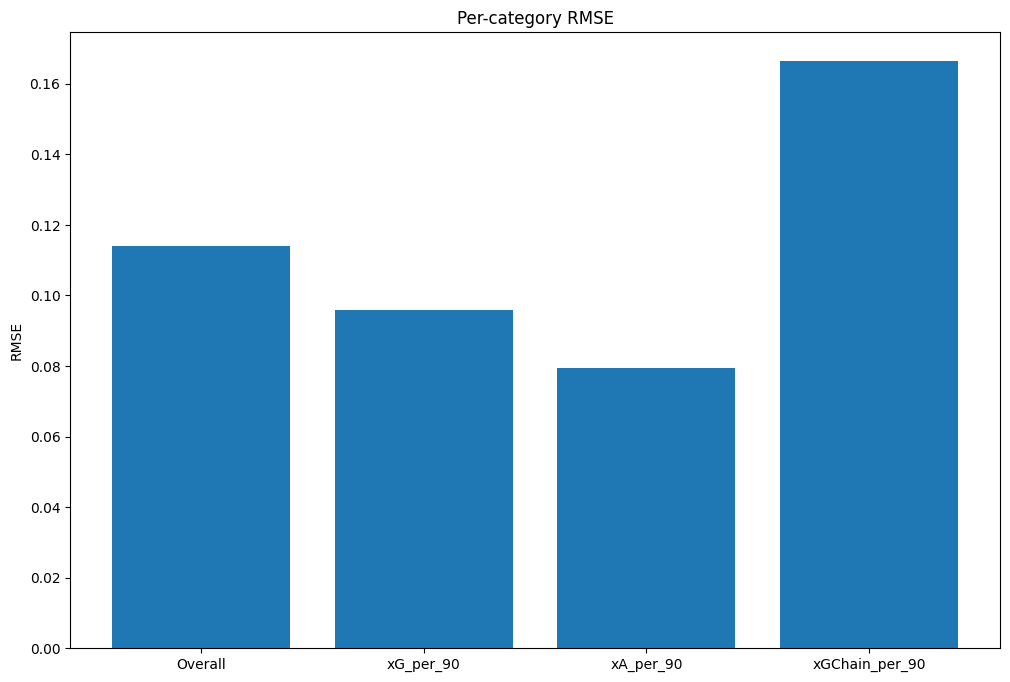

In [16]:
# Evaluate overall test performance

results_dict = model.eval_model(test_dataloader)

# Make bar chart of
cats = ["Overall"]
vals = [results_dict['Overall'][0]]

print(f"Overall test RMSE: {results_dict['Overall'][0]}")
print(f"Overall test MAE: {results_dict['Overall'][1]}")

for i, stat in enumerate(test_df.columns):
    print(f"{stat} test RMSE: {results_dict[i][0]}")
    print(f"{stat} test MAE: {results_dict[i][1]}")
    
    cats.append(stat)
    vals.append(results_dict[i][0])

plt.figure(figsize=(12, 8))
plt.bar(cats,vals)
plt.ylabel("RMSE")
plt.title("Per-category RMSE")

Text(0.5, 1.0, 'Errors over Steps Ahead')

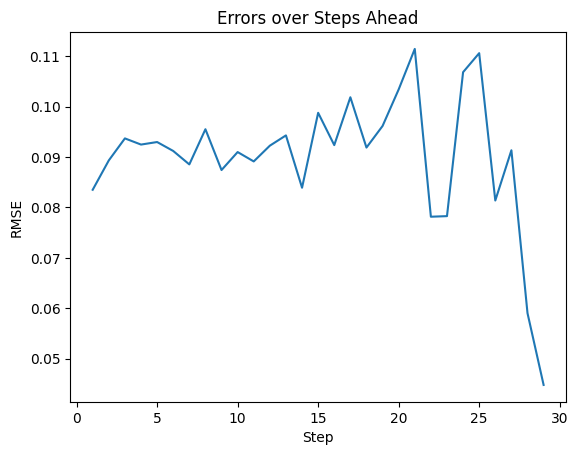

In [17]:
# Look at degredation the further ahead
errors = model.look_ahead_errors(test_dataloader)
plt.plot(errors.keys(), errors.values())
plt.xlabel("Step")
plt.ylabel("RMSE")
plt.title("Errors over Steps Ahead")

RMSE: 0.13692279160022736
MAE: 0.11205074936151505
xG_per_90 RMSE: 0.10719499737024307
xG_per_90 MAE: 0.08956726640462875
xA_per_90 RMSE: 0.13177035748958588
xA_per_90 MAE: 0.11470892280340195
xGChain_per_90 RMSE: 0.17180299758911133
xGChain_per_90 MAE: 0.13187609612941742


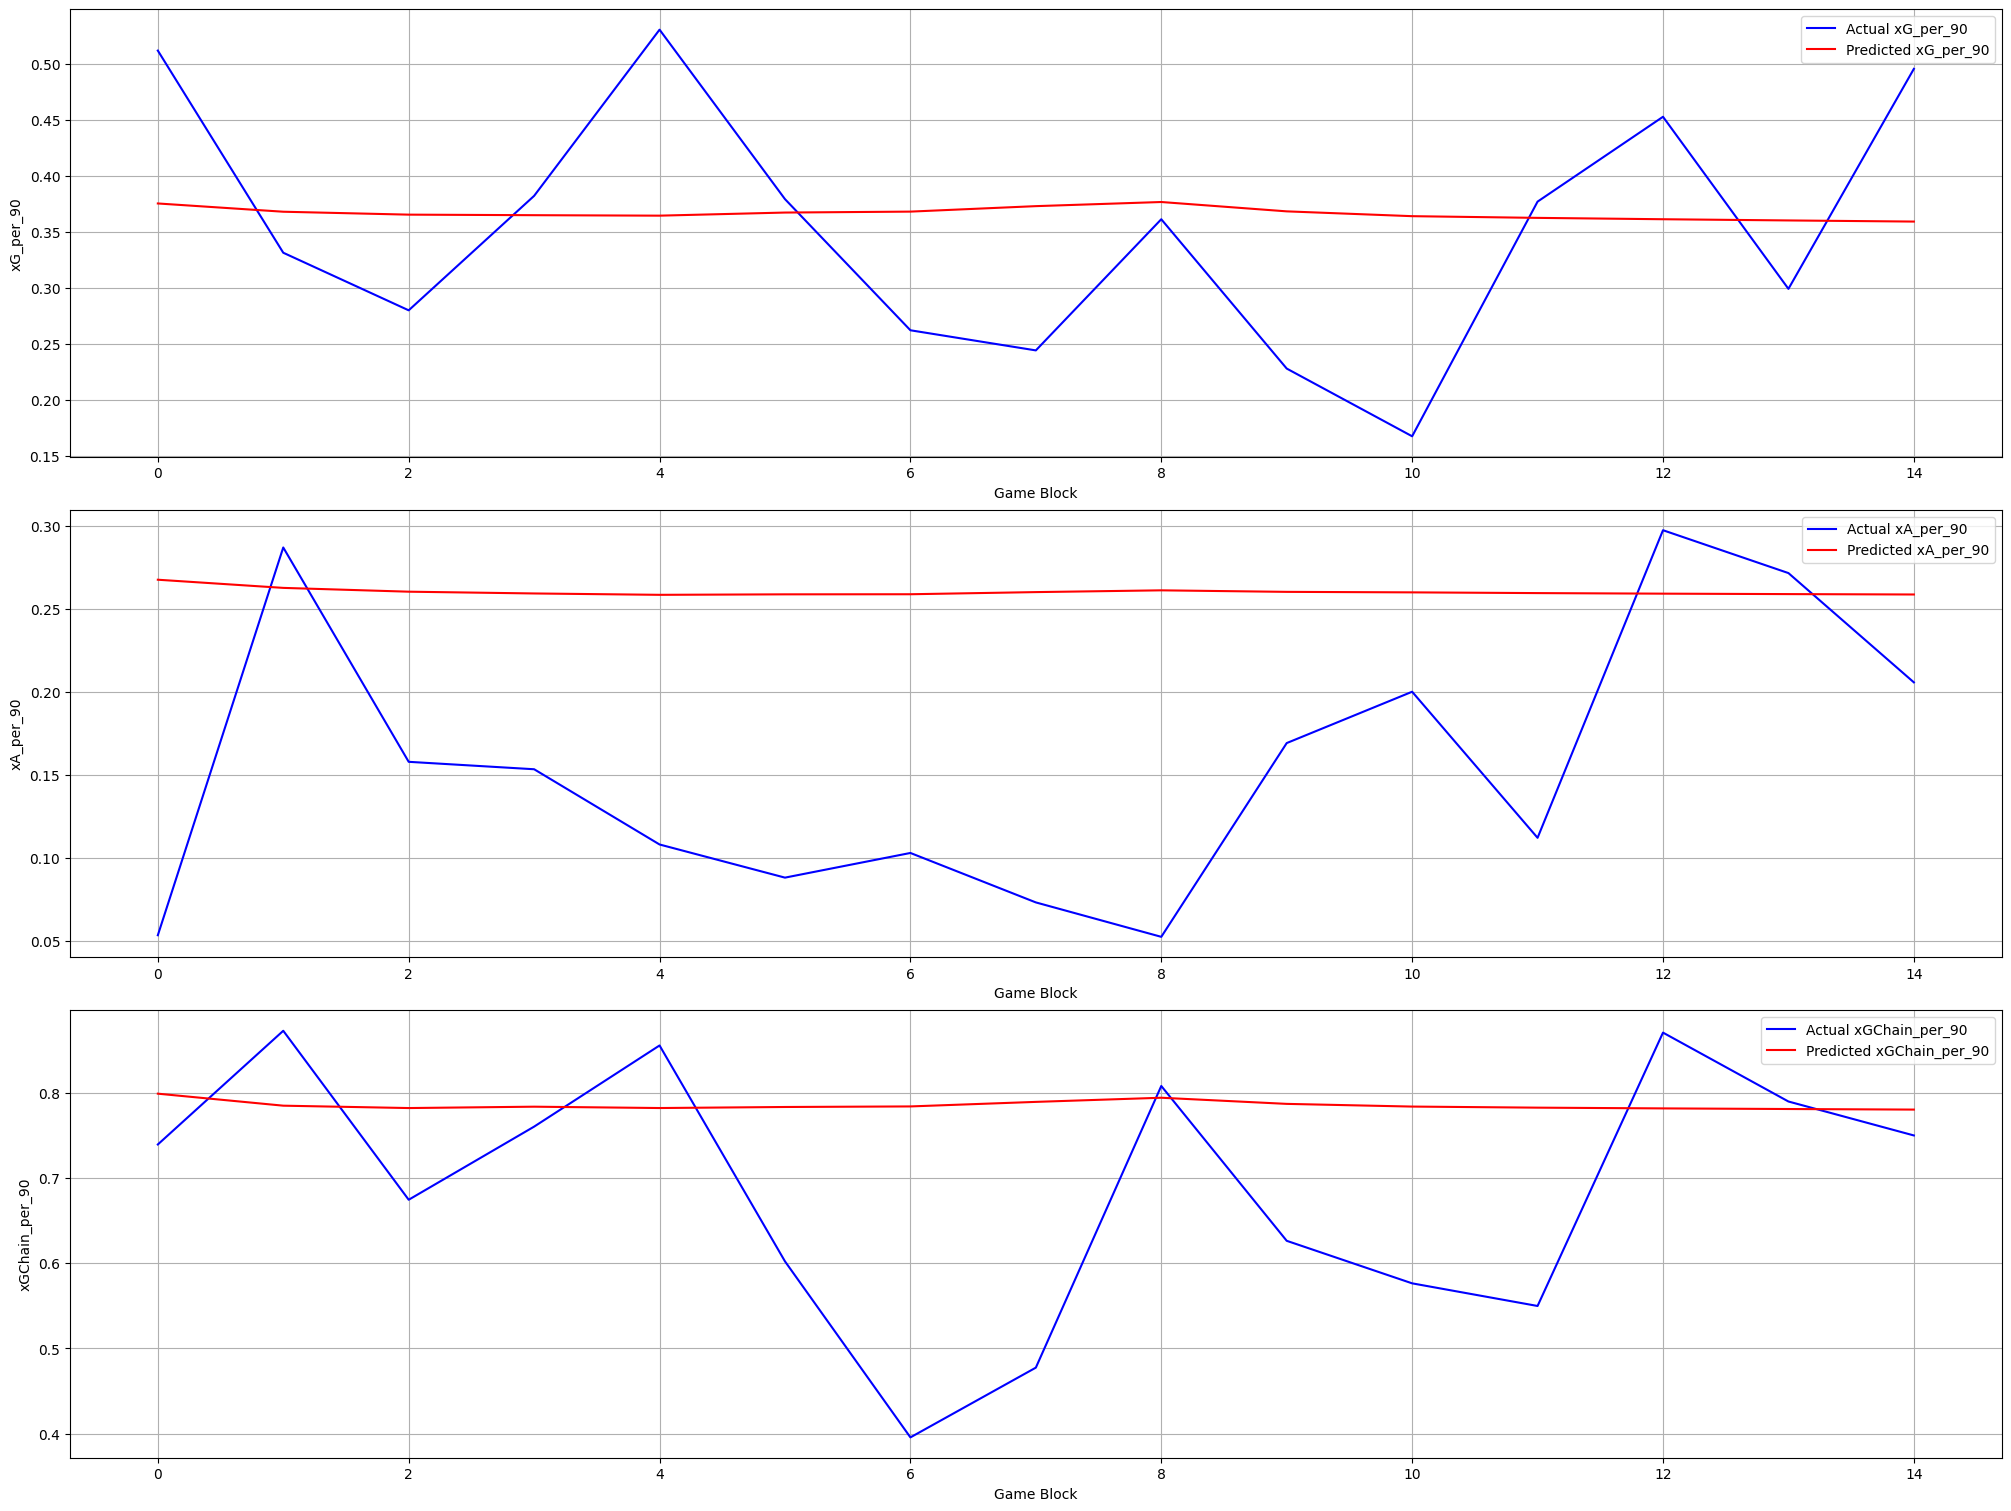

In [18]:
# See how model does on forecasting a specific player

model.eval_model_on_player(stats_df[stats_df.index.get_level_values(1) == "Christian Pulisic"])

In [ ]:
# Pull predictions for test_df and save to csv
preds_df_combined = get_actuals_vs_predictions_df(test_df, model, blocks_per_input=blocks_per_input, max_look_ahead=None)
preds_df_combined.to_csv(f"../data/{'_'.join(positions)}_predictions_real_values.csv", index=False)